In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import joblib
import os

# Load data
X_train = pd.read_csv('../data/processed/X_train_eng.csv')
X_val   = pd.read_csv('../data/processed/X_val_eng.csv')
X_test  = pd.read_csv('../data/processed/X_test_eng.csv')

yr_train = pd.read_csv('../data/processed/yr_train.csv').squeeze()
yr_val   = pd.read_csv('../data/processed/yr_val.csv').squeeze()
yr_test  = pd.read_csv('../data/processed/yr_test.csv').squeeze()

with open('../data/processed/feature_cols_engineered.json') as f:
    feature_cols = json.load(f)

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print(f"\nTarget (max_monthly_emi) stats:")
print(yr_train.describe())

X_train : (283521, 38)
X_val   : (60559, 38)
X_test  : (60720, 38)

Target (max_monthly_emi) stats:
count    283521.000000
mean       6766.363600
std        7753.478944
min         500.000000
25%         500.000000
50%        4200.000000
75%        9792.000000
max       89166.000000
Name: max_monthly_emi, dtype: float64


In [3]:
# Load scaler already saved in Notebook 4
scaler = joblib.load('../models/scaler.pkl')

X_train_scaled = scaler.transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("Scaler loaded and applied successfully")

Scaler loaded and applied successfully


In [4]:
def evaluate_regressor(name, model, X_tr, y_tr, X_v, y_v):
    y_pred_val   = model.predict(X_v)
    y_pred_train = model.predict(X_tr)

    rmse_val  = np.sqrt(mean_squared_error(y_v, y_pred_val))
    rmse_train= np.sqrt(mean_squared_error(y_tr, y_pred_train))
    mae_val   = mean_absolute_error(y_v, y_pred_val)
    r2_val    = r2_score(y_v, y_pred_val)
    mape_val  = np.mean(np.abs((y_v - y_pred_val) / (y_v + 1))) * 100

    results = {
        'Model'      : name,
        'Train RMSE' : round(rmse_train, 2),
        'Val RMSE'   : round(rmse_val, 2),
        'Val MAE'    : round(mae_val, 2),
        'Val R2'     : round(r2_val, 4),
        'Val MAPE %' : round(mape_val, 2)
    }

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    for k, v in results.items():
        if k != 'Model':
            print(f"  {k:<15} : {v}")

    return results

print("Evaluation function ready")

Evaluation function ready


In [5]:
# linear regression
print("Training Linear Regression...")

lr_model = LinearRegression(n_jobs=-1)
lr_model.fit(X_train_scaled, yr_train)

lr_results = evaluate_regressor('Linear Regression', lr_model,
                                 X_train_scaled, yr_train,
                                 X_val_scaled, yr_val)
print("Linear Regression training complete")

Training Linear Regression...

  Linear Regression
  Train RMSE      : 3989.73
  Val RMSE        : 3981.37
  Val MAE         : 2826.28
  Val R2          : 0.7301
  Val MAPE %      : 176.84
Linear Regression training complete


In [6]:
# Decision tree
print("Training Decision Tree Regressor...")

dt_model = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=50,
    min_samples_leaf=20,
    random_state=42
)

dt_model.fit(X_train, yr_train)
dt_results = evaluate_regressor('Decision Tree', dt_model,
                                 X_train, yr_train,
                                 X_val, yr_val)
print("Decision Tree training complete")

Training Decision Tree Regressor...

  Decision Tree
  Train RMSE      : 1252.05
  Val RMSE        : 1300.07
  Val MAE         : 538.49
  Val R2          : 0.9712
  Val MAPE %      : 11.47
Decision Tree training complete


In [7]:
# Random forest
# print("Training Random Forest Regressor... (may take 2-3 minutes)")

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=50,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, yr_train)
rf_results = evaluate_regressor('Random Forest', rf_model,
                                 X_train, yr_train,
                                 X_val, yr_val)
print("Random Forest training complete") 



  Random Forest
  Train RMSE      : 983.95
  Val RMSE        : 1058.75
  Val MAE         : 292.64
  Val R2          : 0.9809
  Val MAPE %      : 7.51
Random Forest training complete


In [8]:
# XGBoost
print("Training XGBoost Regressor... (may take 2-3 minutes)")

xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, yr_train)
xgb_results = evaluate_regressor('XGBoost', xgb_model,
                                  X_train, yr_train,
                                  X_val, yr_val)
print("XGBoost training complete")

Training XGBoost Regressor... (may take 2-3 minutes)

  XGBoost
  Train RMSE      : 722.91
  Val RMSE        : 807.94
  Val MAE         : 310.81
  Val R2          : 0.9889
  Val MAPE %      : 10.79
XGBoost training complete


               Model  Val RMSE  Val MAE  Val R2
0  Linear Regression   3981.37  2826.28  0.7301
1      Decision Tree   1300.07   538.49  0.9712
2      Random Forest   1058.75   292.64  0.9809
3            XGBoost    807.94   310.81  0.9889


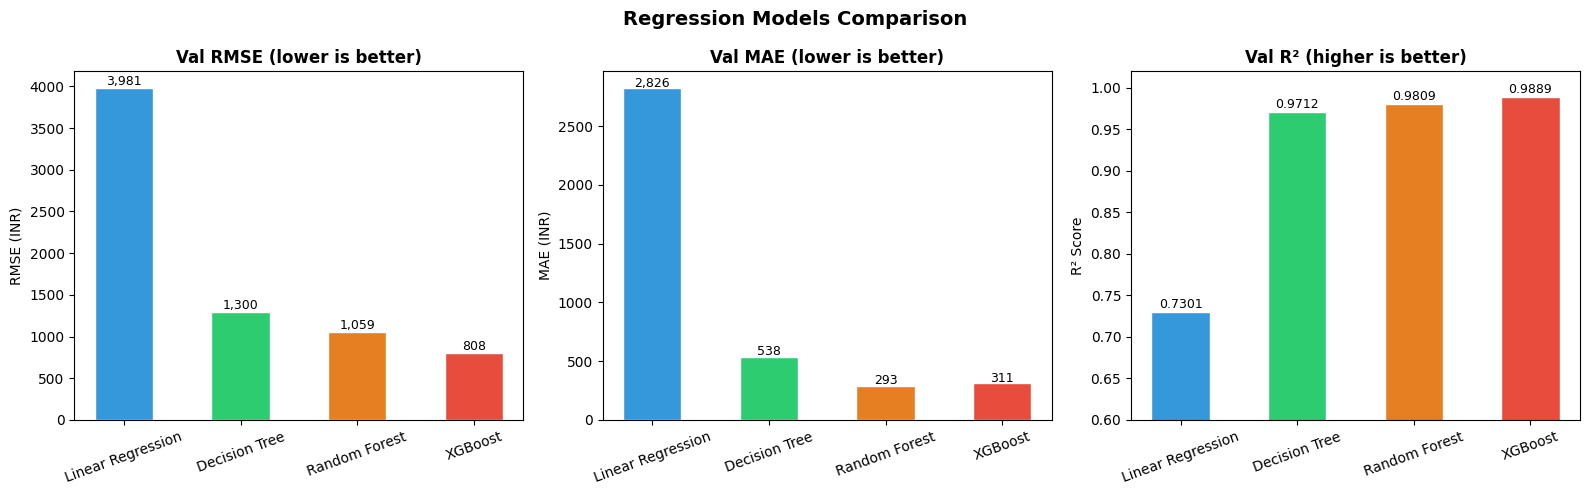

In [9]:
results_list = [lr_results, dt_results, rf_results, xgb_results]
results_df = pd.DataFrame(results_list)

print(results_df[['Model', 'Val RMSE', 'Val MAE', 'Val R2']])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# RMSE — lower is better
bars = axes[0].bar(results_df['Model'], results_df['Val RMSE'],
                   color=['#3498db','#2ecc71','#e67e22','#e74c3c'],
                   edgecolor='white', width=0.5)
axes[0].set_title('Val RMSE (lower is better)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('RMSE (INR)')
axes[0].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, results_df['Val RMSE']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 30,
                 f'{val:,.0f}', ha='center', fontsize=9)

# MAE — lower is better
bars = axes[1].bar(results_df['Model'], results_df['Val MAE'],
                   color=['#3498db','#2ecc71','#e67e22','#e74c3c'],
                   edgecolor='white', width=0.5)
axes[1].set_title('Val MAE (lower is better)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('MAE (INR)')
axes[1].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, results_df['Val MAE']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 10,
                 f'{val:,.0f}', ha='center', fontsize=9)

# R² — higher is better
bars = axes[2].bar(results_df['Model'], results_df['Val R2'],
                   color=['#3498db','#2ecc71','#e67e22','#e74c3c'],
                   edgecolor='white', width=0.5)
axes[2].set_title('Val R² (higher is better)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('R² Score')
axes[2].set_ylim(0.6, 1.02)
axes[2].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, results_df['Val R2']):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{val}', ha='center', fontsize=9)

plt.suptitle('Regression Models Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/regression_comparison.png', dpi=120)
plt.show()

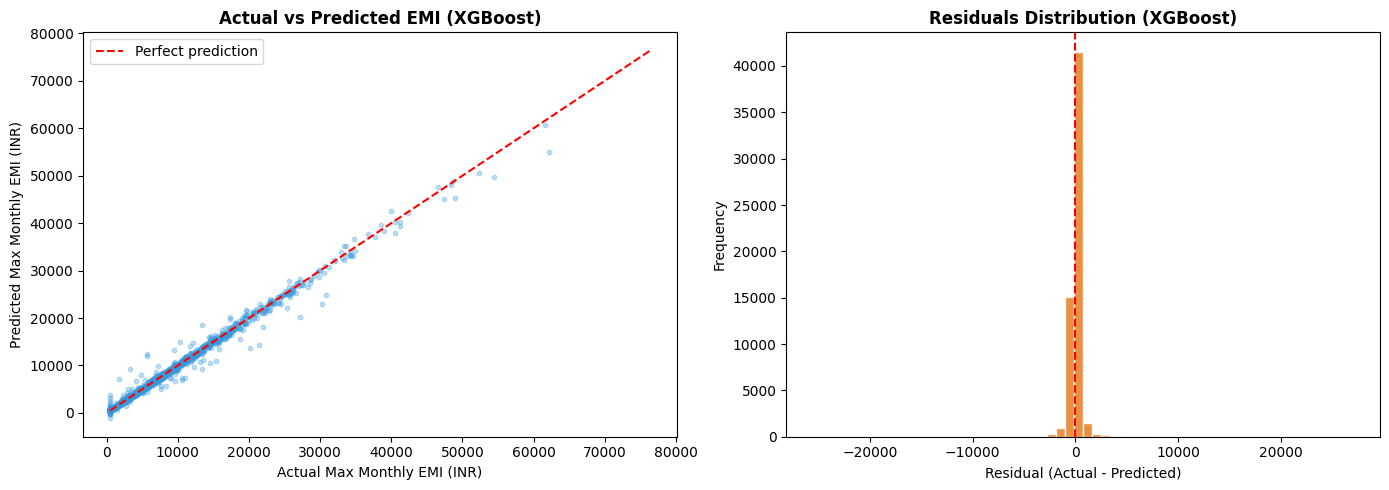

In [ ]:
y_pred_val = xgb_model.predict(X_val)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
sample_idx = np.random.choice(len(yr_val), 2000, replace=False)
axes[0].scatter(yr_val.iloc[sample_idx], y_pred_val[sample_idx],
                alpha=0.3, color='#3498db', s=10)
axes[0].plot([yr_val.min(), yr_val.max()],
             [yr_val.min(), yr_val.max()],
             'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_title('Actual vs Predicted EMI (XGBoost)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Actual Max Monthly EMI (INR)')
axes[0].set_ylabel('Predicted Max Monthly EMI (INR)')
axes[0].legend()

# Residuals plot
residuals = yr_val.values - y_pred_val
axes[1].hist(residuals, bins=60, color='#e67e22', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Residuals Distribution (XGBoost)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../data/processed/xgb_regression_plots.png', dpi=120)
plt.show()

In [ ]:
joblib.dump(xgb_model, '../models/best_regressor.pkl')

print("Best regression model saved: XGBoost")
print(f"Saved to : ../models/best_regressor.pkl")
print(f"\nFinal Test Set Evaluation:")

y_test_pred = xgb_model.predict(X_test)
test_rmse   = np.sqrt(mean_squared_error(yr_test, y_test_pred))
test_mae    = mean_absolute_error(yr_test, y_test_pred)
test_r2     = r2_score(yr_test, y_test_pred)

print(f"Test RMSE : {test_rmse:,.2f} INR")
print(f"Test MAE  : {test_mae:,.2f} INR")
print(f"Test R²   : {test_r2:.4f}")
print(f"\n✅ Notebook 5 Complete — Ready for MLflow Tracking")

Best regression model saved: XGBoost
Saved to : ../models/best_regressor.pkl

Final Test Set Evaluation:
Test RMSE : 796.71 INR
Test MAE  : 309.34 INR
Test R²   : 0.9895

✅ Notebook 5 Complete — Ready for MLflow Tracking
